!pip install pandas, spacy

!python -m spacy download nl_core_news_sm

In [3]:
import pandas as pd

In [4]:
df_taf = pd.read_csv("terugmelding_data/terugmeldingen_afgerond.csv")
df_tdo = pd.read_csv("terugmelding_data/terugmeldingen_doorgestuurd.csv")

In [5]:
df_taf

,meldingsnummer,omschrijving,registratie,status
0,621,Hier is de tramhalte vernieuwd. Er is een extr...,BGT,AFGEROND
1,622,Geen BAG object is fietsenhok. Heeft wel een B...,BGT,AFGEROND
2,623,Geometrie klopt niet.,BGT,AFGEROND
3,624,Voetpad ontbreekt. Overkant straat staat voetp...,BGT,AFGEROND
4,625,Verdrijvingsvlak niet aanwezig,BGT,AFGEROND
...,...,...,...,...
148310,173839,bgt geeft aan dat dit een rijbaan is. Naar mij...,BGT,AFGEROND
148311,173840,bgt geeft aan dat dit een rijbaan is. Naar mij...,BGT,AFGEROND
148312,173842,Hier ligt een verkeerseiland.,BGT,AFGEWEZEN
148313,173843,hier ligt een verkeerseiland.,BGT,AFGEWEZEN


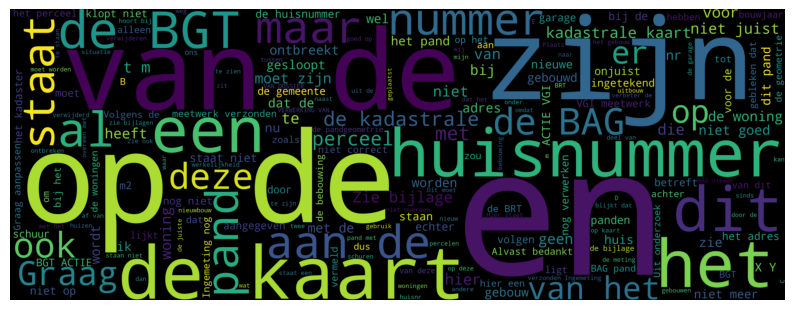

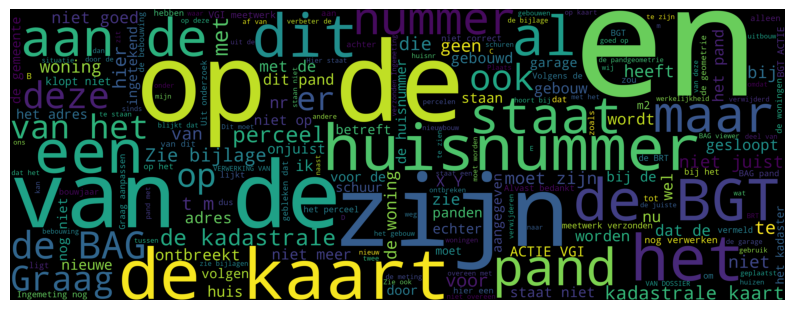

In [6]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def print_wordcloud(data):

  wc = WordCloud(background_color = 'black', height = 1500, width = 4000).generate(data)

  plt.figure(figsize = (10, 20))
  plt.imshow(wc, interpolation = "hamming")

  plt.axis('off')
  plt.show()

# the word cloud function uses one text as input, so we need to concatenate the tweets
cat_tdo = ' '.join(text for text in df_tdo['omschrijving'])
print_wordcloud(cat_tdo)
cat_taf = ' '.join(text for text in df_taf['omschrijving'])
print_wordcloud(cat_tdo)


In [7]:
df_both = pd.concat([df_tdo, df_taf])
df_tdo.shape, df_taf.shape, df_both.shape

((3873, 5), (148315, 4), (152188, 5))

In [8]:
import re


def tokens(text) -> list[str]:
    """List all the word tokens (consecutive letters) in a text. Normalize to lowercase."""
    return re.findall('[a-z]+', text.lower())

cat_all = ' '.join(df_both['omschrijving'])
tokens_all = tokens(cat_all)
tokens_tdo = tokens(cat_tdo)
tokens_taf = tokens(cat_taf)


In [9]:
import math
from collections import Counter

counts_all = Counter(tokens_all)
counts_tdo = Counter(tokens_tdo)
counts_taf = Counter(tokens_taf)

frequency_tdo = {token: counts_tdo[token] / counts_all[token] for token in counts_tdo if counts_all[token]}
frequency_taf = {token: counts_taf[token] / counts_all[token] for token in counts_taf if counts_all[token]}

frequency_tdo_sorted = pd.Series(frequency_tdo).sort_values(ascending=False)
df_freq_tdo = pd.concat([frequency_tdo_sorted, pd.Series(counts_tdo)], axis=1).sort_values(by=[0, 1], ascending=False)
df_freq_tdo

,0,1
skutmakkersp,1.000000,4
melkdreef,1.000000,4
vormer,1.000000,3
hartholtstraat,1.000000,3
talhaoui,1.000000,3
...,...,...
ongeluk,0.001149,1
beheerder,0.000927,2
gebruiksdoel,0.000736,3
schermafdruk,0.000608,1


In [17]:
len(counts_all)

60587

(array([6.0325e+04, 1.2600e+02, 4.8000e+01, 3.0000e+01, 8.0000e+00,
        4.0000e+00, 5.0000e+00, 5.0000e+00, 5.0000e+00, 3.0000e+00,
        2.0000e+00, 5.0000e+00, 2.0000e+00, 0.0000e+00, 1.0000e+00,
        3.0000e+00, 2.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 2.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        2.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.00

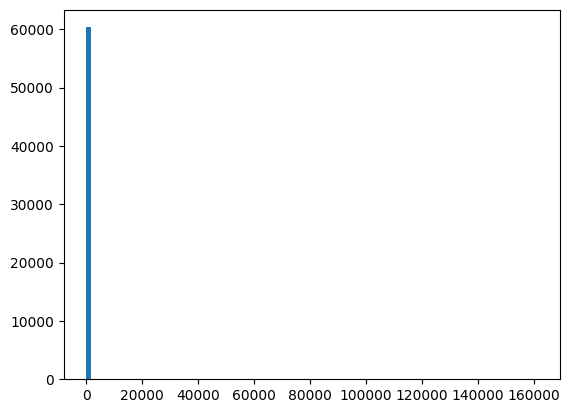

In [18]:
import matplotlib.pyplot as plt

plt.hist(counts_all.values(), bins=100)


In [22]:
sorted(counts_all, key=counts_all.get, reverse=True)[:10]

['de', 'is', 'het', 'van', 'in', 'en', 'een', 'dit', 'niet', 'op']

(array([6.0325e+04, 1.2600e+02, 4.8000e+01, 3.0000e+01, 8.0000e+00,
        4.0000e+00, 5.0000e+00, 5.0000e+00, 5.0000e+00, 3.0000e+00,
        2.0000e+00, 5.0000e+00, 2.0000e+00, 0.0000e+00, 1.0000e+00,
        3.0000e+00, 2.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 2.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        2.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.00

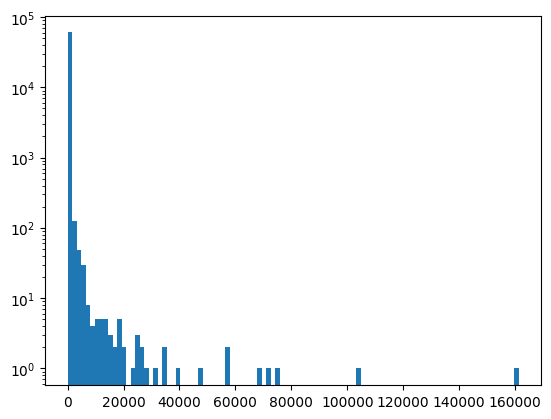

In [20]:
plt.hist(counts_all.values(), bins=100, log=True)

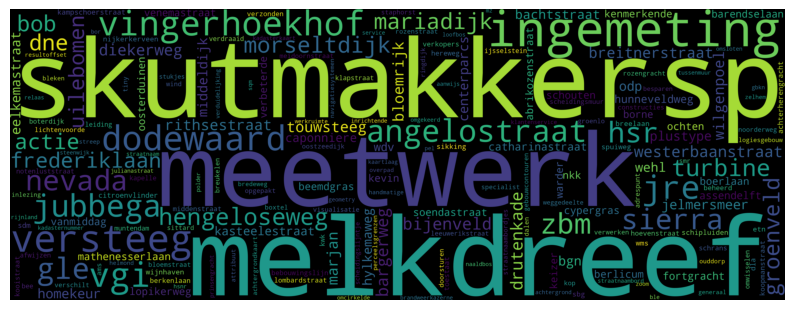

In [10]:
df_freq_tdo.columns = ['frequency', 'count']

df_freq_tdo = df_freq_tdo.query('count > 3')

wc = WordCloud(background_color = 'black', height = 1500, width = 4000).fit_words(df_freq_tdo.frequency.to_dict())

plt.figure(figsize = (10, 20))
plt.imshow(wc, interpolation = "hamming")

plt.axis('off')
plt.show()


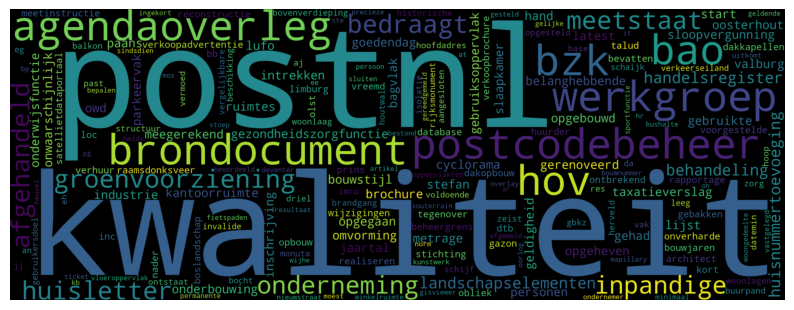

In [13]:
df_freq_taf = pd.concat([pd.Series(frequency_taf), pd.Series(counts_taf)], axis=1).sort_values(by=[0, 1], ascending=False)

df_freq_taf.columns = ['frequency', 'count']

df_freq_taf = df_freq_taf.query('count > 3')

wc = WordCloud(background_color = 'black', height = 1500, width = 4000).fit_words(df_freq_taf.frequency.to_dict())

plt.figure(figsize = (10, 20))
plt.imshow(wc, interpolation = "hamming")

plt.axis('off')
plt.show()

In [16]:
import spacy
from spacy import displacy

nlp = spacy.load('nl_core_news_sm')
print("tdo")
docs = [nlp(doc) for doc in df_tdo['omschrijving'][:10]]
displacy.render(docs, style="ent", options={"compact": True, "distance": 100})
print("taf")
docs = [nlp(doc) for doc in df_taf['omschrijving'][:10].tolist()]
displacy.render(docs, style="ent", options={"compact": True, "distance": 100})


tdo


/Users/hprins/Code/workshop-text-mining/.venv/lib/python3.9/site-packages/spacy/displacy/__init__.py:215: UserWarning: [W006] No entities to visualize found in Doc object. If this is surprising to you, make sure the Doc was processed using a model that supports named entity recognition, and check the `doc.ents` property manually if necessary.
  warnings.warn(Warnings.W006)


taf
